In [1]:
# Imports
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
%matplotlib inline

In [2]:
# Oracle circuit with winning state |11>
oracle_c = QuantumCircuit(2, name = "Oracle Circuit")

oracle_c.cz(0, 1)

oracle_gate = oracle_c.to_gate()

In [3]:
# Reflection circuit
reflection_c = QuantumCircuit(2, name = "Reflection Circuit")

reflection_c.h([0, 1])
reflection_c.z([0, 1])
reflection_c.cz(0, 1)
reflection_c.h([0, 1])

reflection_gate = reflection_c.to_gate()

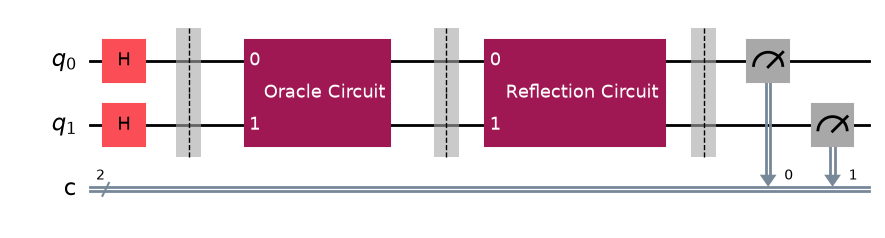

In [4]:
# Main circuit
main_c = QuantumCircuit(2, 2)

main_c.h([0, 1])
main_c.barrier()

main_c.append(oracle_gate, [0, 1])
main_c.barrier()

main_c.append(reflection_gate, [0, 1])
main_c.barrier()

main_c.measure([0, 1], [0, 1])

main_c.draw(output="mpl");

In [6]:
simulator = AerSimulator()
result = simulator.run(main_c.decompose(), shots=1024).result()
counts = result.get_counts()

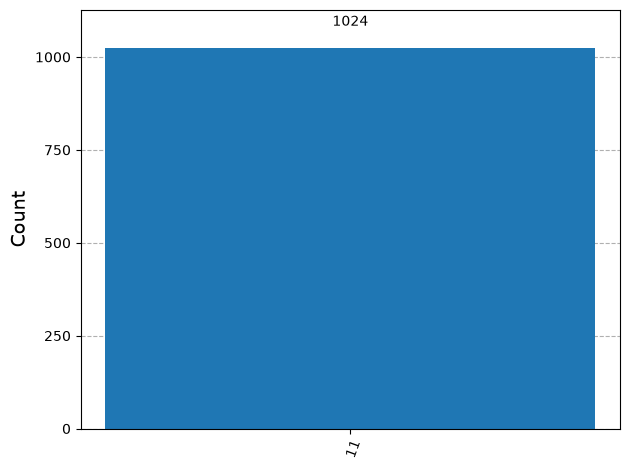

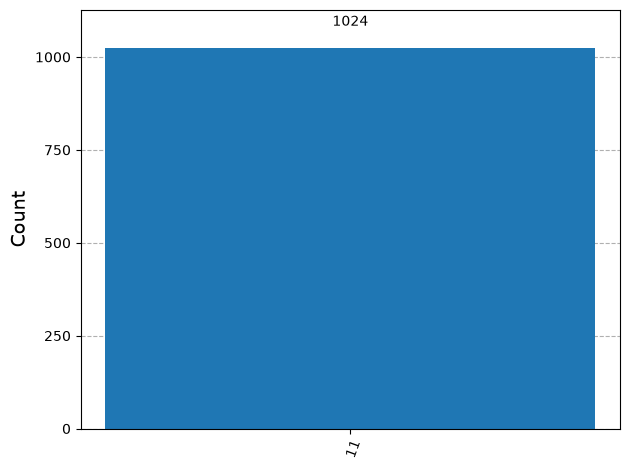

In [7]:
plot_histogram(counts);